In [1]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
df = pd.read_csv("../data/best_model_result/best_model_result.csv")

#Ajustamos el nombre de los mdodelos
mapeo_modelos = {
    'kmeans': 'K-Means Clustering',
    'ac': 'Agglomerative Clustering',
    'gmm': 'Gaussian Mixture Models'
}
# Esto reemplaza los valores en la columna actual
df['modelo'] = df['modelo'].map(mapeo_modelos)

# Verifica el resultado
df.head()

,modelo,k,silhouette,calinski_harabasz
0,K-Means Clustering,2,0.334066,9689.738733
1,K-Means Clustering,3,0.286471,7534.655743
2,K-Means Clustering,4,0.261612,6260.782560
3,K-Means Clustering,5,0.250583,5496.228994
4,K-Means Clustering,6,0.260726,5172.484621


In [3]:
import plotly.express as px

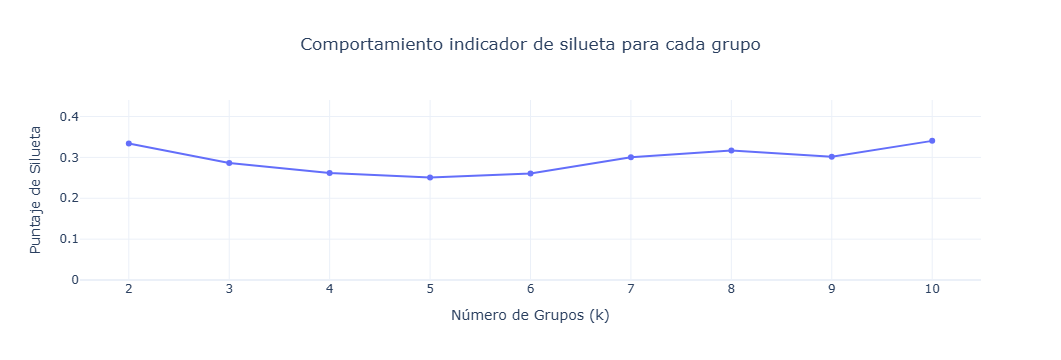

In [4]:
df_km = df[df["modelo"] == 	"K-Means Clustering" ]

fig_silhouette = px.line(
    df_km,
    x="k",
    y="silhouette",
    markers=True,
    template="plotly_white",
    labels={"k": "Número de Grupos (k)", "silhouette": "Puntaje de Silueta"},
    title="Comportamiento indicador de silueta para cada grupo"
)



fig_silhouette.update_layout(
    title_x=0.5, # Centra el título
    hovermode="x unified", # Muestra el valor al pasar el mouse sobre el eje X
    yaxis_range=[0, df_km['silhouette'].max() + 0.1] # Ajusta el eje Y para ver mejor la escala
)

fig_silhouette.show()

In [5]:
df_cluster = pd.read_csv("../data/clean/homeris-data-clean-cluster.csv")

mapeo_cluster = {
    2:'Grupo A',
    9:'Grupo B'
}

df_cluster["cluster"] = df_cluster["cluster"].map(mapeo_cluster)
df_cluster["cluster"].value_counts()

cluster
Grupo A    9280
Grupo B    5403
Name: count, dtype: int64